# Wheat / Corn / Soybean Feature Overview

Loads `data/ag/wheat.csv`, `data/ag/corn.csv`, and `data/ag/soybean.csv`, prints summary statistics for every feature, and plots feature time series.

Each crop file shares the same 139 columns:
- **Endogenous RV-family features**: `{crop}_{horizon}_{metric}` for `crop in {wheat, corn, soybeans}`, `horizon in {weekly, monthly, seasonal}`, and `metric in {rv, rvg, rvb, rsk, rku, jumps, tru, trd, lev}`. These are identical across all three files. Only `weekly_rv` is plotted here.
- **Crop-specific seasonal climate features**: `*_in_planting` / `*_in_harvesting` columns whose values differ per crop file (different planting/harvesting windows). The `spi_*` family is limited to the 7-day window (`spi_7d`); `spi_1m` and `spi_3m` are skipped.
- **Shared global features** (climate indices, news, macro): identical across all three files.

For each feature, the time series for wheat, corn, and soybean are plotted together so they can be compared directly. Plots are arranged in a grid of 4 per row for compact, paper-ready figures.

In [1]:
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from src.util.path import DATA_DIR

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# Set to True to export each figure (PDF + PNG) for the paper.
SAVE_FIGURES = True
FIGURES_DIR = project_root / "notebooks" / "figures" / "feature_overview"
if SAVE_FIGURES:
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## Load data

In [2]:
CROP_FILES = {"wheat": "wheat.csv", "corn": "corn.csv", "soybean": "soybean.csv"}
# Column prefix used inside each file differs slightly for soybean ("soybeans").
CROP_PREFIX = {"wheat": "wheat", "corn": "corn", "soybean": "soybeans"}

dfs = {}
for crop, fname in CROP_FILES.items():
    df = pd.read_csv(DATA_DIR / "ag" / fname, parse_dates=["date"])
    df = df.set_index("date")
    dfs[crop] = df
    print(f"{crop}: {df.shape}")

reference_df = dfs["wheat"]

wheat: (832, 138)
corn: (832, 138)
soybean: (832, 138)


## Descriptive statistics

`describe()` for every feature in each crop file.

In [3]:
for crop, df in dfs.items():
    print(f"\n=== {crop.title()} ({CROP_FILES[crop]}) — "
          f"describe() for {df.shape[1]} features ===")
    display(df.describe().T)


=== Wheat (wheat.csv) — describe() for 138 features ===


,count,mean,std,min,25%,50%,75%,max
corn_weekly_rv,832.0,0.012834,0.004125,0.005733,0.009958,0.011944,0.014695,0.034829
corn_weekly_rvg,832.0,0.008983,0.002924,0.003731,0.006982,0.008382,0.010378,0.027826
corn_weekly_rvb,832.0,0.008950,0.002954,0.003841,0.006937,0.008338,0.010166,0.024582
corn_weekly_rsk,832.0,0.060053,0.683995,-3.273934,-0.341875,0.057251,0.452230,2.452036
corn_weekly_rku,832.0,10.683959,4.926638,4.056842,7.718501,9.419132,12.051364,44.965295
corn_weekly_jumps,832.0,0.000037,0.000050,0.000002,0.000017,0.000024,0.000038,0.000733
corn_weekly_tru,832.0,0.000073,0.000070,0.000007,0.000035,0.000053,0.000087,0.000996
corn_weekly_trd,832.0,0.000071,0.000068,0.000007,0.000034,0.000053,0.000084,0.000779
corn_weekly_lev,832.0,0.007087,0.123339,-0.366468,-0.075583,0.006448,0.094159,0.391713
corn_monthly_rv,832.0,0.012834,0.003564,0.006972,0.010286,0.012131,0.014589,0.024373



=== Corn (corn.csv) — describe() for 138 features ===


,count,mean,std,min,25%,50%,75%,max
corn_weekly_rv,832.0,0.012834,0.004125,0.005733,0.009958,0.011944,0.014695,0.034829
corn_weekly_rvg,832.0,0.008983,0.002924,0.003731,0.006982,0.008382,0.010378,0.027826
corn_weekly_rvb,832.0,0.008950,0.002954,0.003841,0.006937,0.008338,0.010166,0.024582
corn_weekly_rsk,832.0,0.060053,0.683995,-3.273934,-0.341875,0.057251,0.452230,2.452036
corn_weekly_rku,832.0,10.683959,4.926638,4.056842,7.718501,9.419132,12.051364,44.965295
corn_weekly_jumps,832.0,0.000037,0.000050,0.000002,0.000017,0.000024,0.000038,0.000733
corn_weekly_tru,832.0,0.000073,0.000070,0.000007,0.000035,0.000053,0.000087,0.000996
corn_weekly_trd,832.0,0.000071,0.000068,0.000007,0.000034,0.000053,0.000084,0.000779
corn_weekly_lev,832.0,0.007087,0.123339,-0.366468,-0.075583,0.006448,0.094159,0.391713
corn_monthly_rv,832.0,0.012834,0.003564,0.006972,0.010286,0.012131,0.014589,0.024373



=== Soybean (soybean.csv) — describe() for 138 features ===


,count,mean,std,min,25%,50%,75%,max
corn_weekly_rv,832.0,0.012834,0.004125,0.005733,0.009958,0.011944,0.014695,0.034829
corn_weekly_rvg,832.0,0.008983,0.002924,0.003731,0.006982,0.008382,0.010378,0.027826
corn_weekly_rvb,832.0,0.008950,0.002954,0.003841,0.006937,0.008338,0.010166,0.024582
corn_weekly_rsk,832.0,0.060053,0.683995,-3.273934,-0.341875,0.057251,0.452230,2.452036
corn_weekly_rku,832.0,10.683959,4.926638,4.056842,7.718501,9.419132,12.051364,44.965295
corn_weekly_jumps,832.0,0.000037,0.000050,0.000002,0.000017,0.000024,0.000038,0.000733
corn_weekly_tru,832.0,0.000073,0.000070,0.000007,0.000035,0.000053,0.000087,0.000996
corn_weekly_trd,832.0,0.000071,0.000068,0.000007,0.000034,0.000053,0.000084,0.000779
corn_weekly_lev,832.0,0.007087,0.123339,-0.366468,-0.075583,0.006448,0.094159,0.391713
corn_monthly_rv,832.0,0.012834,0.003564,0.006972,0.010286,0.012131,0.014589,0.024373


## Helper: grid plotting

Lays out a list of `(title, plot_fn)` panels in a grid with a fixed number of columns per row, where `plot_fn(ax)` draws into the given axes.

In [4]:
def plot_grid(specs, ncols=4, panel_size=(5, 3.5), save_name=None):
    n = len(specs)
    ncols = min(ncols, n)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(panel_size[0] * ncols, panel_size[1] * nrows)
    )
    axes = np.atleast_1d(axes).ravel()
    for ax, (title, plot_fn) in zip(axes, specs):
        plot_fn(ax)
        ax.set_title(title)
        ax.set_xlabel("Date")
    for ax in axes[len(specs):]:
        ax.axis("off")
    plt.tight_layout()
    if SAVE_FIGURES and save_name:
        fig.savefig(FIGURES_DIR / f"{save_name}.pdf")
        fig.savefig(FIGURES_DIR / f"{save_name}.png", dpi=150)
    plt.show()
    plt.close(fig)

## Weekly realized volatility

Cross-crop comparison of `weekly_rv` only (the other RV-family metrics and horizons are skipped).

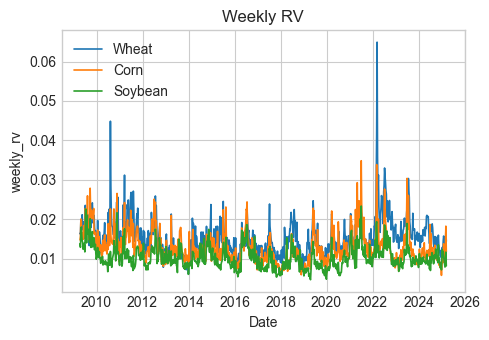

In [5]:
def plot_weekly_rv(ax):
    for crop, prefix in CROP_PREFIX.items():
        col = f"{prefix}_weekly_rv"
        ax.plot(reference_df.index, reference_df[col], label=crop.title(), linewidth=1.2)
    ax.set_ylabel("weekly_rv")
    ax.legend()

plot_grid([("Weekly RV", plot_weekly_rv)], ncols=4, save_name="endo_weekly_rv")

## Crop-specific seasonal climate features

`*_in_planting` / `*_in_harvesting` columns share the same name across files but differ in value per crop (different planting/harvesting windows), so each crop's own series is plotted. The `spi_*` family is limited to `spi_7d` (`spi_1m` and `spi_3m` are skipped).

30 crop-specific climate features (of 46, spi limited to spi_7d)


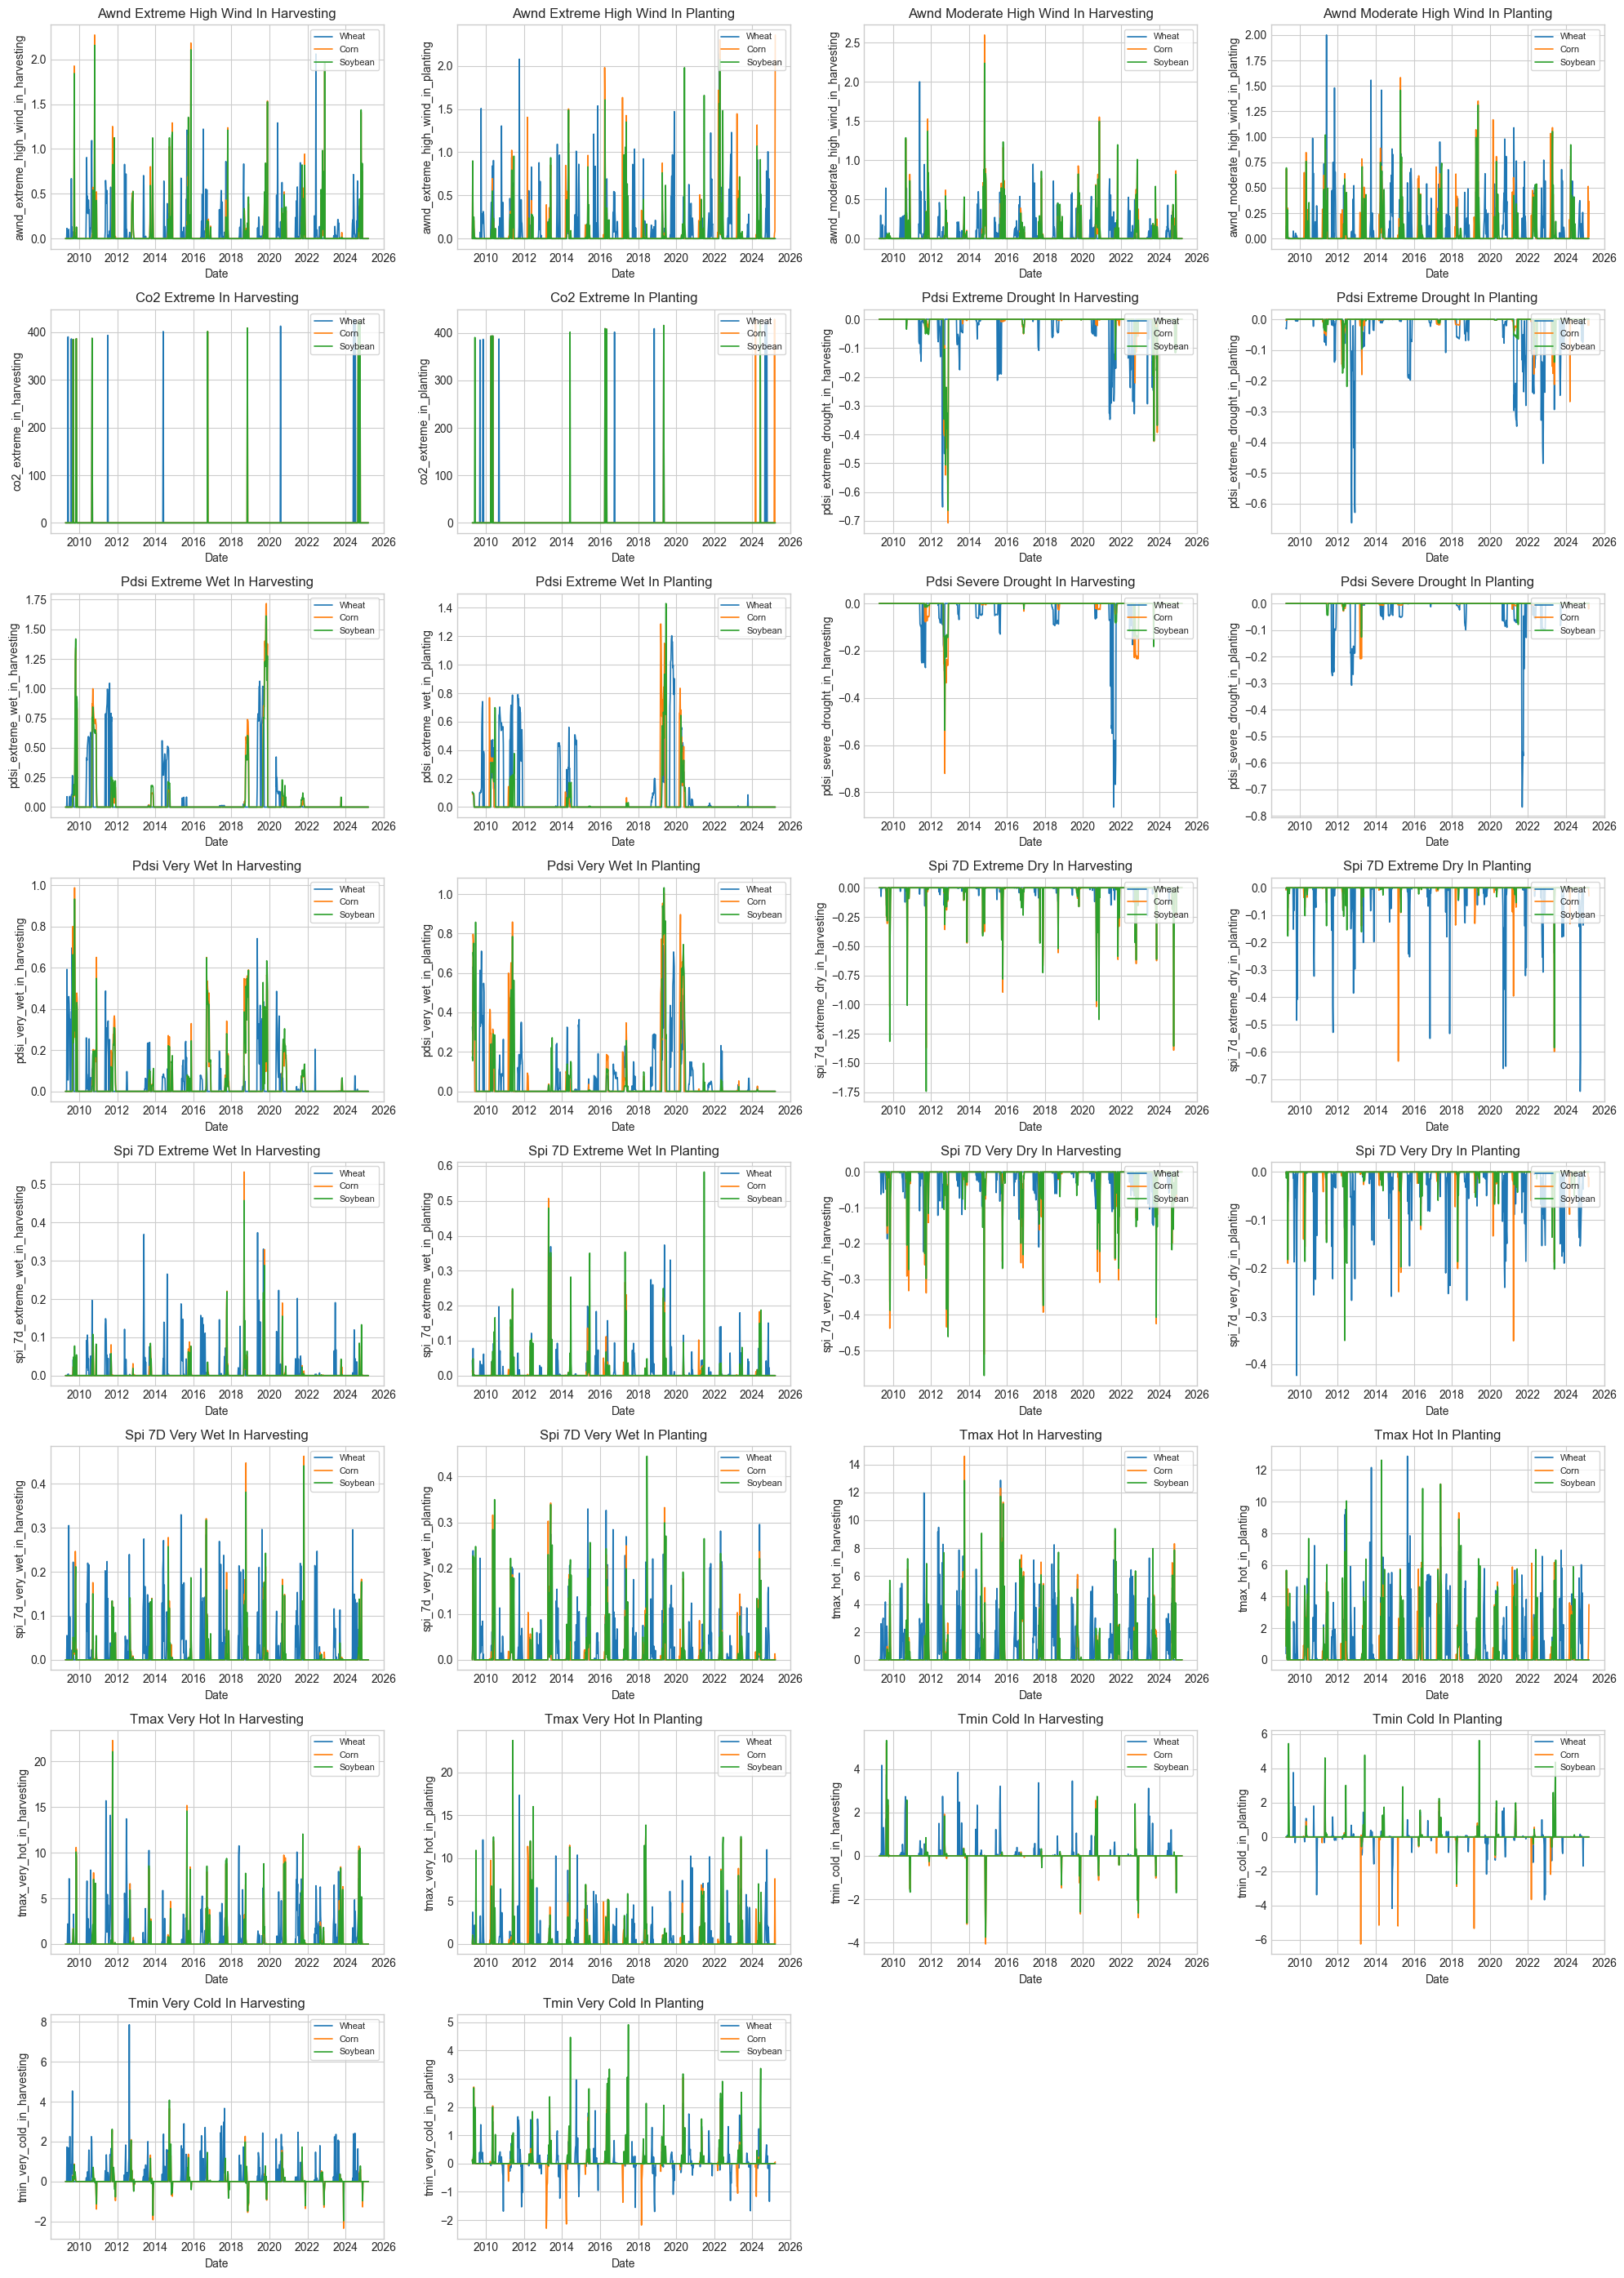

In [6]:
ALL_CLIMATE_FEATURES = sorted(
    col for col in reference_df.columns
    if col.endswith("_in_planting") or col.endswith("_in_harvesting")
)
CLIMATE_FEATURES = [
    col for col in ALL_CLIMATE_FEATURES
    if not col.startswith("spi_1m_") and not col.startswith("spi_3m_")
]
print(f"{len(CLIMATE_FEATURES)} crop-specific climate features "
      f"(of {len(ALL_CLIMATE_FEATURES)}, spi limited to spi_7d)")

def make_climate_plot(col):
    def plot_fn(ax):
        for crop, df in dfs.items():
            ax.plot(df.index, df[col], label=crop.title(), linewidth=1.2)
        ax.set_ylabel(col)
        ax.legend(loc='upper right', bbox_to_anchor=(1.0, 1.0), fontsize=8, frameon=True)
    return plot_fn

climate_specs = [
    (col.replace("_", " ").title(), make_climate_plot(col)) for col in CLIMATE_FEATURES
]
plot_grid(climate_specs, ncols=4, save_name="climate_features_grid")

## Shared macro / climate-index / sentiment features

These columns are identical across the three files, so they are plotted once from the wheat file.

11 shared global features


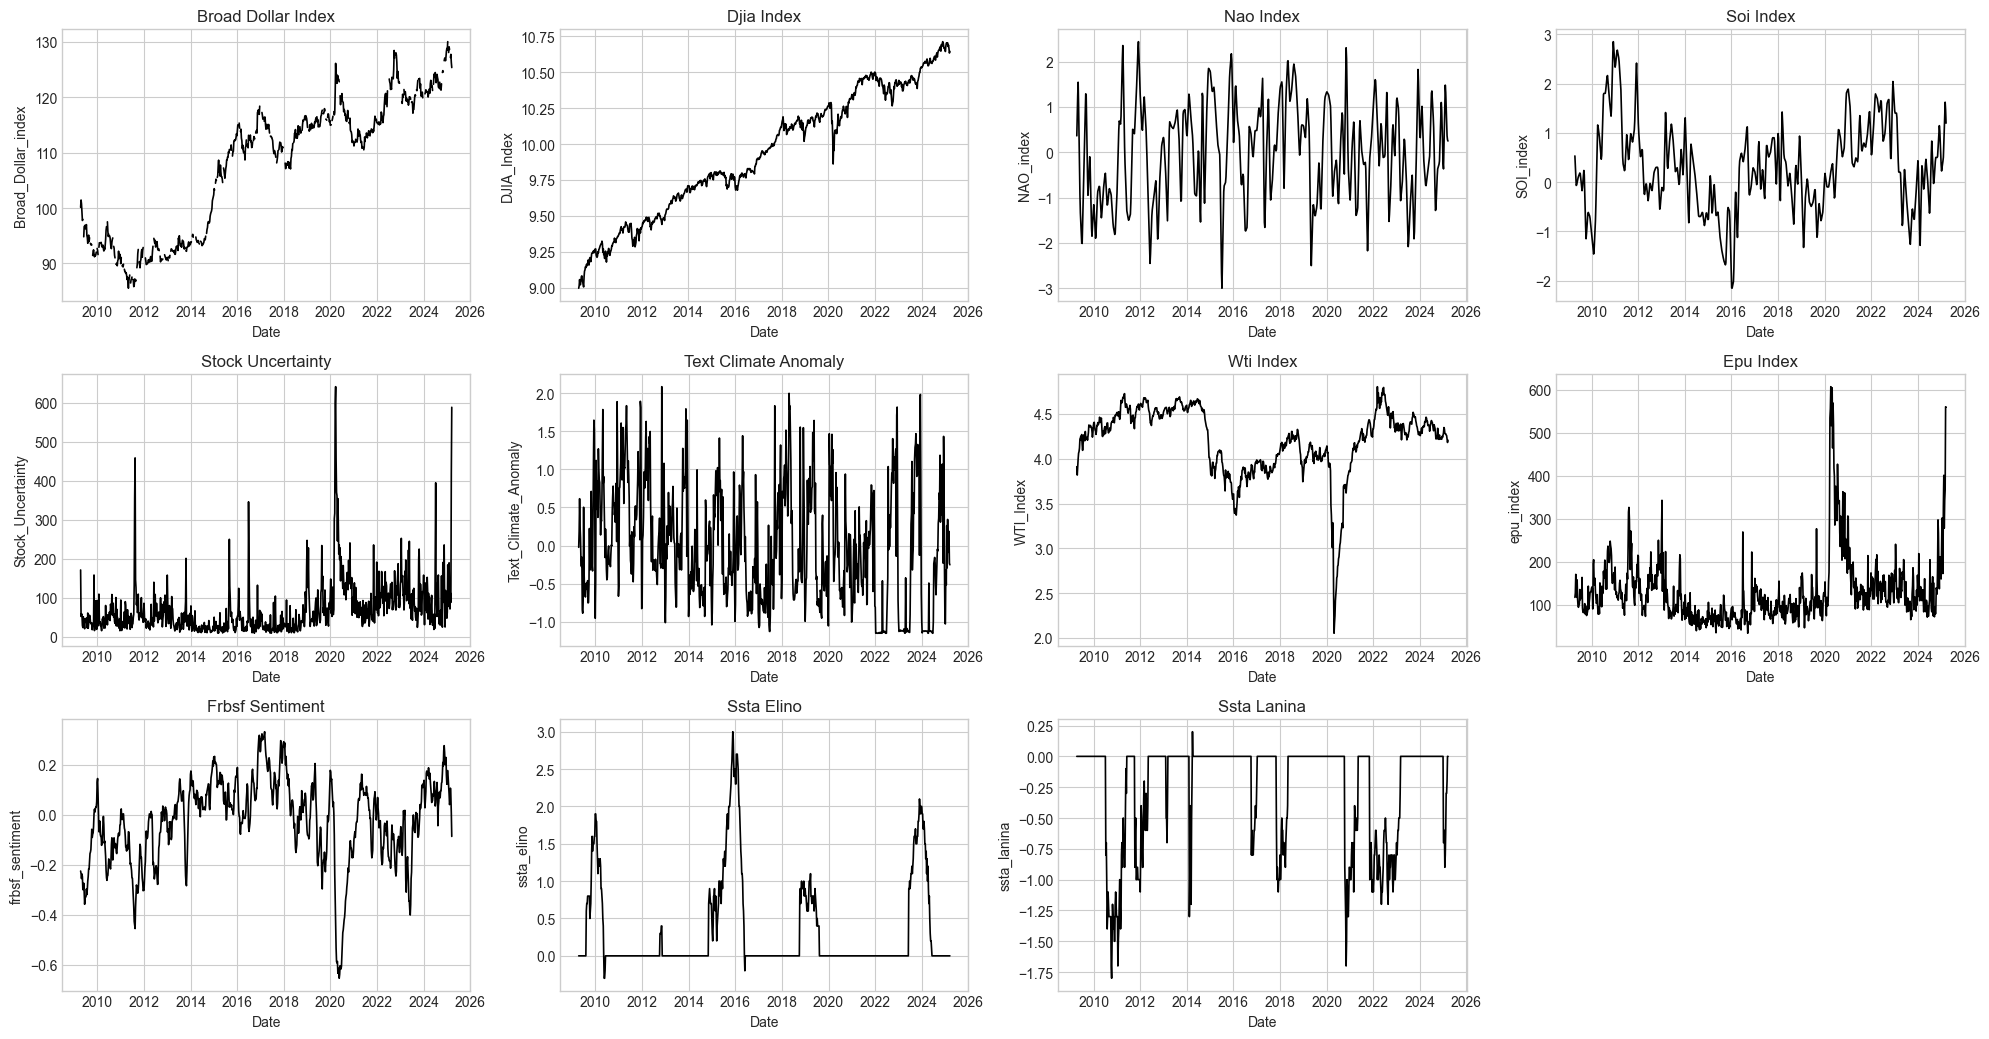

In [7]:
endo_cols = {
    f"{prefix}_{h}_{m}"
    for prefix in CROP_PREFIX.values()
    for h in ["weekly", "monthly", "seasonal"]
    for m in ["rv", "rvg", "rvb", "rsk", "rku", "jumps", "tru", "trd", "lev"]
}
GLOBAL_FEATURES = sorted(
    set(reference_df.columns) - endo_cols - set(ALL_CLIMATE_FEATURES)
)
print(f"{len(GLOBAL_FEATURES)} shared global features")

def make_global_plot(col):
    def plot_fn(ax):
        ax.plot(reference_df.index, reference_df[col], color="black", linewidth=1.2)
        ax.set_ylabel(col)
    return plot_fn

global_specs = [
    (col.replace("_", " ").title(), make_global_plot(col)) for col in GLOBAL_FEATURES
]
plot_grid(global_specs, ncols=4, save_name="global_features_grid")